In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path


In [2]:
# Mount Google Drive only when on Colab; on a local machine this is a no-op.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')


Not running on Colab — skipping drive.mount.


In [3]:
# Dataset root.  Expected layout: DATA_DIR/<emperor_folder>/side_a/*.jpg
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'


In [4]:
# Build the same label encoder used at extraction time so the cached
# embeddings still line up with class names.
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes = len(label_encoder)
print(f'{num_classes} classes from folder structure.')


52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


In [6]:
# Reuse cached embeddings from emp_model_v2.ipynb — no re-extraction needed.
embeddings_path = Path(DATA_DIR) / 'cradio_v4_embeddings.pt'
saved = torch.load(embeddings_path)
all_feats, all_labs = saved['features'], saved['labels']
print(f'Loaded embeddings: {all_feats.shape}')


FileNotFoundError: [Errno 2] No such file or directory: '/home/david/coin/FOR_TRAINNING/cradio_v4_embeddings.pt'

In [7]:
# Merge tiny / hard-to-distinguish classes BEFORE training (same as v2_merged).
MERGES = {
    'GORDIAN II': 'GORDIAN I',
}

remap = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label = {v: k for k, v in label_encoder.items()}
num_classes = len(label_encoder)

print(f'After merge: {num_classes} classes.')


After merge: 51 classes.


In [8]:
# Stratified train / val / test split (identical seeds to v2 for fair comparison).
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')

# ------------------- class-balanced "effective number" weights (Cui et al. 2019)
class_counts = torch.bincount(train_labs, minlength=num_classes).float()
beta = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights = (1.0 - beta) / effective_num
cb_weights = cb_weights / cb_weights.sum() * num_classes   # mean ~= 1
cb_weights = cb_weights.to(device)
print('Class-balanced weights ready  min/mean/max:',
      f'{cb_weights.min():.3f} / {cb_weights.mean():.3f} / {cb_weights.max():.3f}')


Train: 39912  Val: 9979  Test: 12473
Class-balanced weights ready  min/mean/max: 0.346 / 1.000 / 3.134


In [9]:
# Loaders.  We use a WeightedRandomSampler so rare classes are seen more often
# AND keep class weights inside the loss — together they smooth the imbalance.
batch_size = 512

sample_weights = cb_weights.cpu()[train_labs]
train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_labs), replacement=True
)

train_loader = DataLoader(
    TensorDataset(train_feats, train_labs), batch_size=batch_size, sampler=train_sampler
)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)
print('Loaders ready.')


Loaders ready.


In [10]:
# Train / Val / Test image counts per emperor (chronological by folder prefix).
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()

per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))
print(f"\nTotals -> Train: {per_class_counts.Train.sum()}  Val: {per_class_counts.Val.sum()}"
      f"  Test: {per_class_counts.Test.sum()}  ({len(per_class_counts)} classes)")


 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1080  270   338   1688
 2          TIBERIUS    528  132   165    825
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    884  221   276   1381
 5              NERO    958  239   299   1496
 6             GALBA    995  249   311   1555
 7              OTHO    411  103   129    643
 8         VITELLIUS    570  143   178    891
 9         VESPASIAN   1361  341   426   2128
10             TITUS   1123  281   351   1755
11          DOMITIAN   1313  329   410   2052
12             NERVA   1106  276   345   1727
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   246   1228
18          COMMODUS   1125  281   351   1757
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   159    793
21  SEPTIMUS SEVERUS   1553  388  

In [11]:
# ===== Model: MLP backbone + cosine classifier head =====
#
# Why this design:
#   * MLP gives more capacity for fine-grained portrait separation than a single Linear.
#   * LayerNorm + Dropout are the regulariser pair that consistently outperforms
#     BatchNorm on frozen-feature classifiers.
#   * The final layer is a *cosine* classifier (weight-normalised) with a learnable
#     scale.  On fine-grained tasks (CUB / Cars / Dogs / coins) this typically beats
#     a plain Linear by 0.5–2 pts and is more robust to class imbalance because the
#     decision boundary depends on angle rather than magnitude.

class CosineClassifier(nn.Module):
    def __init__(self, in_dim, n_cls, scale=20.0):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim) * 0.01)
        self.log_scale = nn.Parameter(torch.tensor(float(np.log(scale))))

    def forward(self, x):
        x = F.normalize(x, dim=-1)
        w = F.normalize(self.weight, dim=-1)
        return torch.exp(self.log_scale) * (x @ w.T)


class CoinHead(nn.Module):
    def __init__(self, in_dim, n_cls, hidden=1024, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = CosineClassifier(hidden, n_cls)

    def forward(self, x):
        return self.cls(self.body(x))


feat_dim = train_feats.shape[1]
print(f'Building head:  {feat_dim} -> 1024 -> 1024 -> cosine[{num_classes}]')


Building head:  2560 -> 1024 -> 1024 -> cosine[51]


In [12]:
# ===== Mixup, label-smoothing CE, cosine LR schedule with warmup =====
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def smoothed_ce(logits, y_a, y_b, lam, weight, smoothing=0.1):
    log_p = F.log_softmax(logits, dim=-1)
    n_cls = logits.size(1)
    # weighted, smoothed CE -- manual to support mixup + per-class weights
    def one(y):
        # weighted smoothing target
        w = weight[y].unsqueeze(1) if weight is not None else 1.0
        # log-prob of true class (weighted)
        nll = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        # uniform component
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [13]:
# ===== One full training run, parameterised by seed =====
def train_one_head(seed, epochs=60, lr=3e-4, weight_decay=1e-2,
                   mixup_alpha=0.2, smoothing=0.1, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = CoinHead(feat_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, epochs * steps_per_epoch,
                               warmup_steps=2 * steps_per_epoch)

    best_val_acc, best_state = 0.0, None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)
            mixed, y_a, y_b, lam = mixup_batch(feats, targets, alpha=mixup_alpha)
            optimizer.zero_grad()
            logits = model(mixed)
            loss = smoothed_ce(logits, y_a, y_b, lam, cb_weights, smoothing=smoothing)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        train_loss = running / len(train_loader)

        model.eval()
        v_loss = 0.0; v_correct = 0; v_total = 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                logits = model(feats)
                # plain CE for val (with class weights, no smoothing/mixup)
                v_loss += F.cross_entropy(logits, targets, weight=cb_weights).item()
                v_correct += (logits.argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_loss = v_loss / len(val_loader)
        val_acc  = v_correct / v_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 5 == 0 or improved):
            dt = datetime.now() - t0
            mark = ' <-- best' if improved else ''
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'train {train_loss:.4f}  val {val_loss:.4f}  acc {val_acc:.4f}  '
                  f'lr {lr_now:.2e}  [{dt}]{mark}')

    model.load_state_dict(best_state)
    return model, best_val_acc, history


In [14]:
# ===== Train an ensemble of N heads with different seeds =====
N_MODELS = 5
EPOCHS   = 60

ensemble = []
for k in range(N_MODELS):
    print(f'\n=== Training head {k + 1}/{N_MODELS} ===')
    m, vacc, _ = train_one_head(seed=1000 + k, epochs=EPOCHS, verbose=(k == 0))
    print(f'  -> best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], 'emp_model_v3_ensemble.pth')
print(f'\nSaved {N_MODELS} heads -> emp_model_v3_ensemble.pth')



=== Training head 1/5 ===
[seed 1000] ep   1/60  train 3.2235  val 1.6513  acc 0.4513  lr 1.50e-04  [0:00:01.079682] <-- best
[seed 1000] ep   2/60  train 1.9937  val 1.0038  acc 0.6855  lr 3.00e-04  [0:00:00.539521] <-- best
[seed 1000] ep   3/60  train 1.8663  val 0.8898  acc 0.7195  lr 3.00e-04  [0:00:00.614538] <-- best
[seed 1000] ep   4/60  train 1.7824  val 0.8013  acc 0.7607  lr 2.99e-04  [0:00:00.474804] <-- best
[seed 1000] ep   5/60  train 1.7840  val 0.7559  acc 0.7578  lr 2.98e-04  [0:00:00.464622]
[seed 1000] ep   6/60  train 1.7008  val 0.6957  acc 0.7871  lr 2.96e-04  [0:00:00.450838] <-- best
[seed 1000] ep   8/60  train 1.6421  val 0.6828  acc 0.7900  lr 2.92e-04  [0:00:00.436653] <-- best
[seed 1000] ep  10/60  train 1.5398  val 0.6803  acc 0.7915  lr 2.86e-04  [0:00:00.442815] <-- best
[seed 1000] ep  11/60  train 1.5965  val 0.6629  acc 0.7947  lr 2.83e-04  [0:00:00.470001] <-- best
[seed 1000] ep  12/60  train 1.5612  val 0.6246  acc 0.8063  lr 2.79e-04  [0:00:00

In [15]:
# ===== Ensemble + kNN inference =====
#
# Two complementary classifiers built on the same frozen features:
#   1.  Ensemble of MLP heads -> average softmax probabilities.
#   2.  Cosine-kNN over the training embeddings (similarity-weighted vote).
#
# The kNN classifier is parameter-free, sees a different bias than the MLP, and
# typically helps on fine-grained classes where a linear boundary blurs together
# closely-related portrait styles.

@torch.no_grad()
def ensemble_probs(feats):
    feats = feats.to(device)
    probs = None
    for m in ensemble:
        p = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


# Pre-compute L2-normalised training features once
train_norm = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)


@torch.no_grad()
def knn_probs(feats, K=25, temperature=20.0):
    """Similarity-weighted soft kNN vote, returned as a class probability vector."""
    q = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm.T            # (B, N_train)
    vals, idx = sims.topk(K, dim=-1)   # (B, K)
    weights = F.softmax(vals * temperature, dim=-1)
    neigh_labs = train_labs_dev[idx]   # (B, K)
    out = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, neigh_labs, weights)
    return out


@torch.no_grad()
def fused_predict(feats, alpha):
    """alpha = weight on kNN; (1-alpha) on the ensemble."""
    p_ens = ensemble_probs(feats)
    p_knn = knn_probs(feats)
    return (1 - alpha) * p_ens + alpha * p_knn


In [16]:
# Pick the kNN fusion weight on val.
def accuracy_with_alpha(loader, alpha):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs = fused_predict(feats, alpha)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    return correct / total

for a in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    acc = accuracy_with_alpha(val_loader, a)
    print(f'alpha = {a:.2f}  val acc = {acc:.4f}')

best_alpha = max([0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
                 key=lambda a: accuracy_with_alpha(val_loader, a))
print(f'\nBest alpha on val: {best_alpha}')


alpha = 0.00  val acc = 0.8722
alpha = 0.10  val acc = 0.8738
alpha = 0.20  val acc = 0.8738
alpha = 0.30  val acc = 0.8745
alpha = 0.40  val acc = 0.8747
alpha = 0.50  val acc = 0.8717

Best alpha on val: 0.4


In [17]:
def evaluate(loader, alpha, name):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs = fused_predict(feats, alpha)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name} accuracy: {acc:.4f} ({correct}/{total})')
    return acc

# Ensemble only (alpha = 0)
print('--- Ensemble only ---')
evaluate(train_loader, 0.0, 'Train')
evaluate(val_loader,   0.0, 'Val')
evaluate(test_loader,  0.0, 'Test')

# Ensemble + kNN
print(f'\n--- Ensemble + kNN (alpha = {best_alpha}) ---')
evaluate(train_loader, best_alpha, 'Train')
evaluate(val_loader,   best_alpha, 'Val')
evaluate(test_loader,  best_alpha, 'Test')


--- Ensemble only ---
Train accuracy: 0.9469 (37793/39912)
Val accuracy: 0.8722 (8704/9979)
Test accuracy: 0.8736 (10897/12473)

--- Ensemble + kNN (alpha = 0.4) ---
Train accuracy: 0.9455 (37738/39912)
Val accuracy: 0.8747 (8729/9979)
Test accuracy: 0.8751 (10915/12473)


0.875090194820813

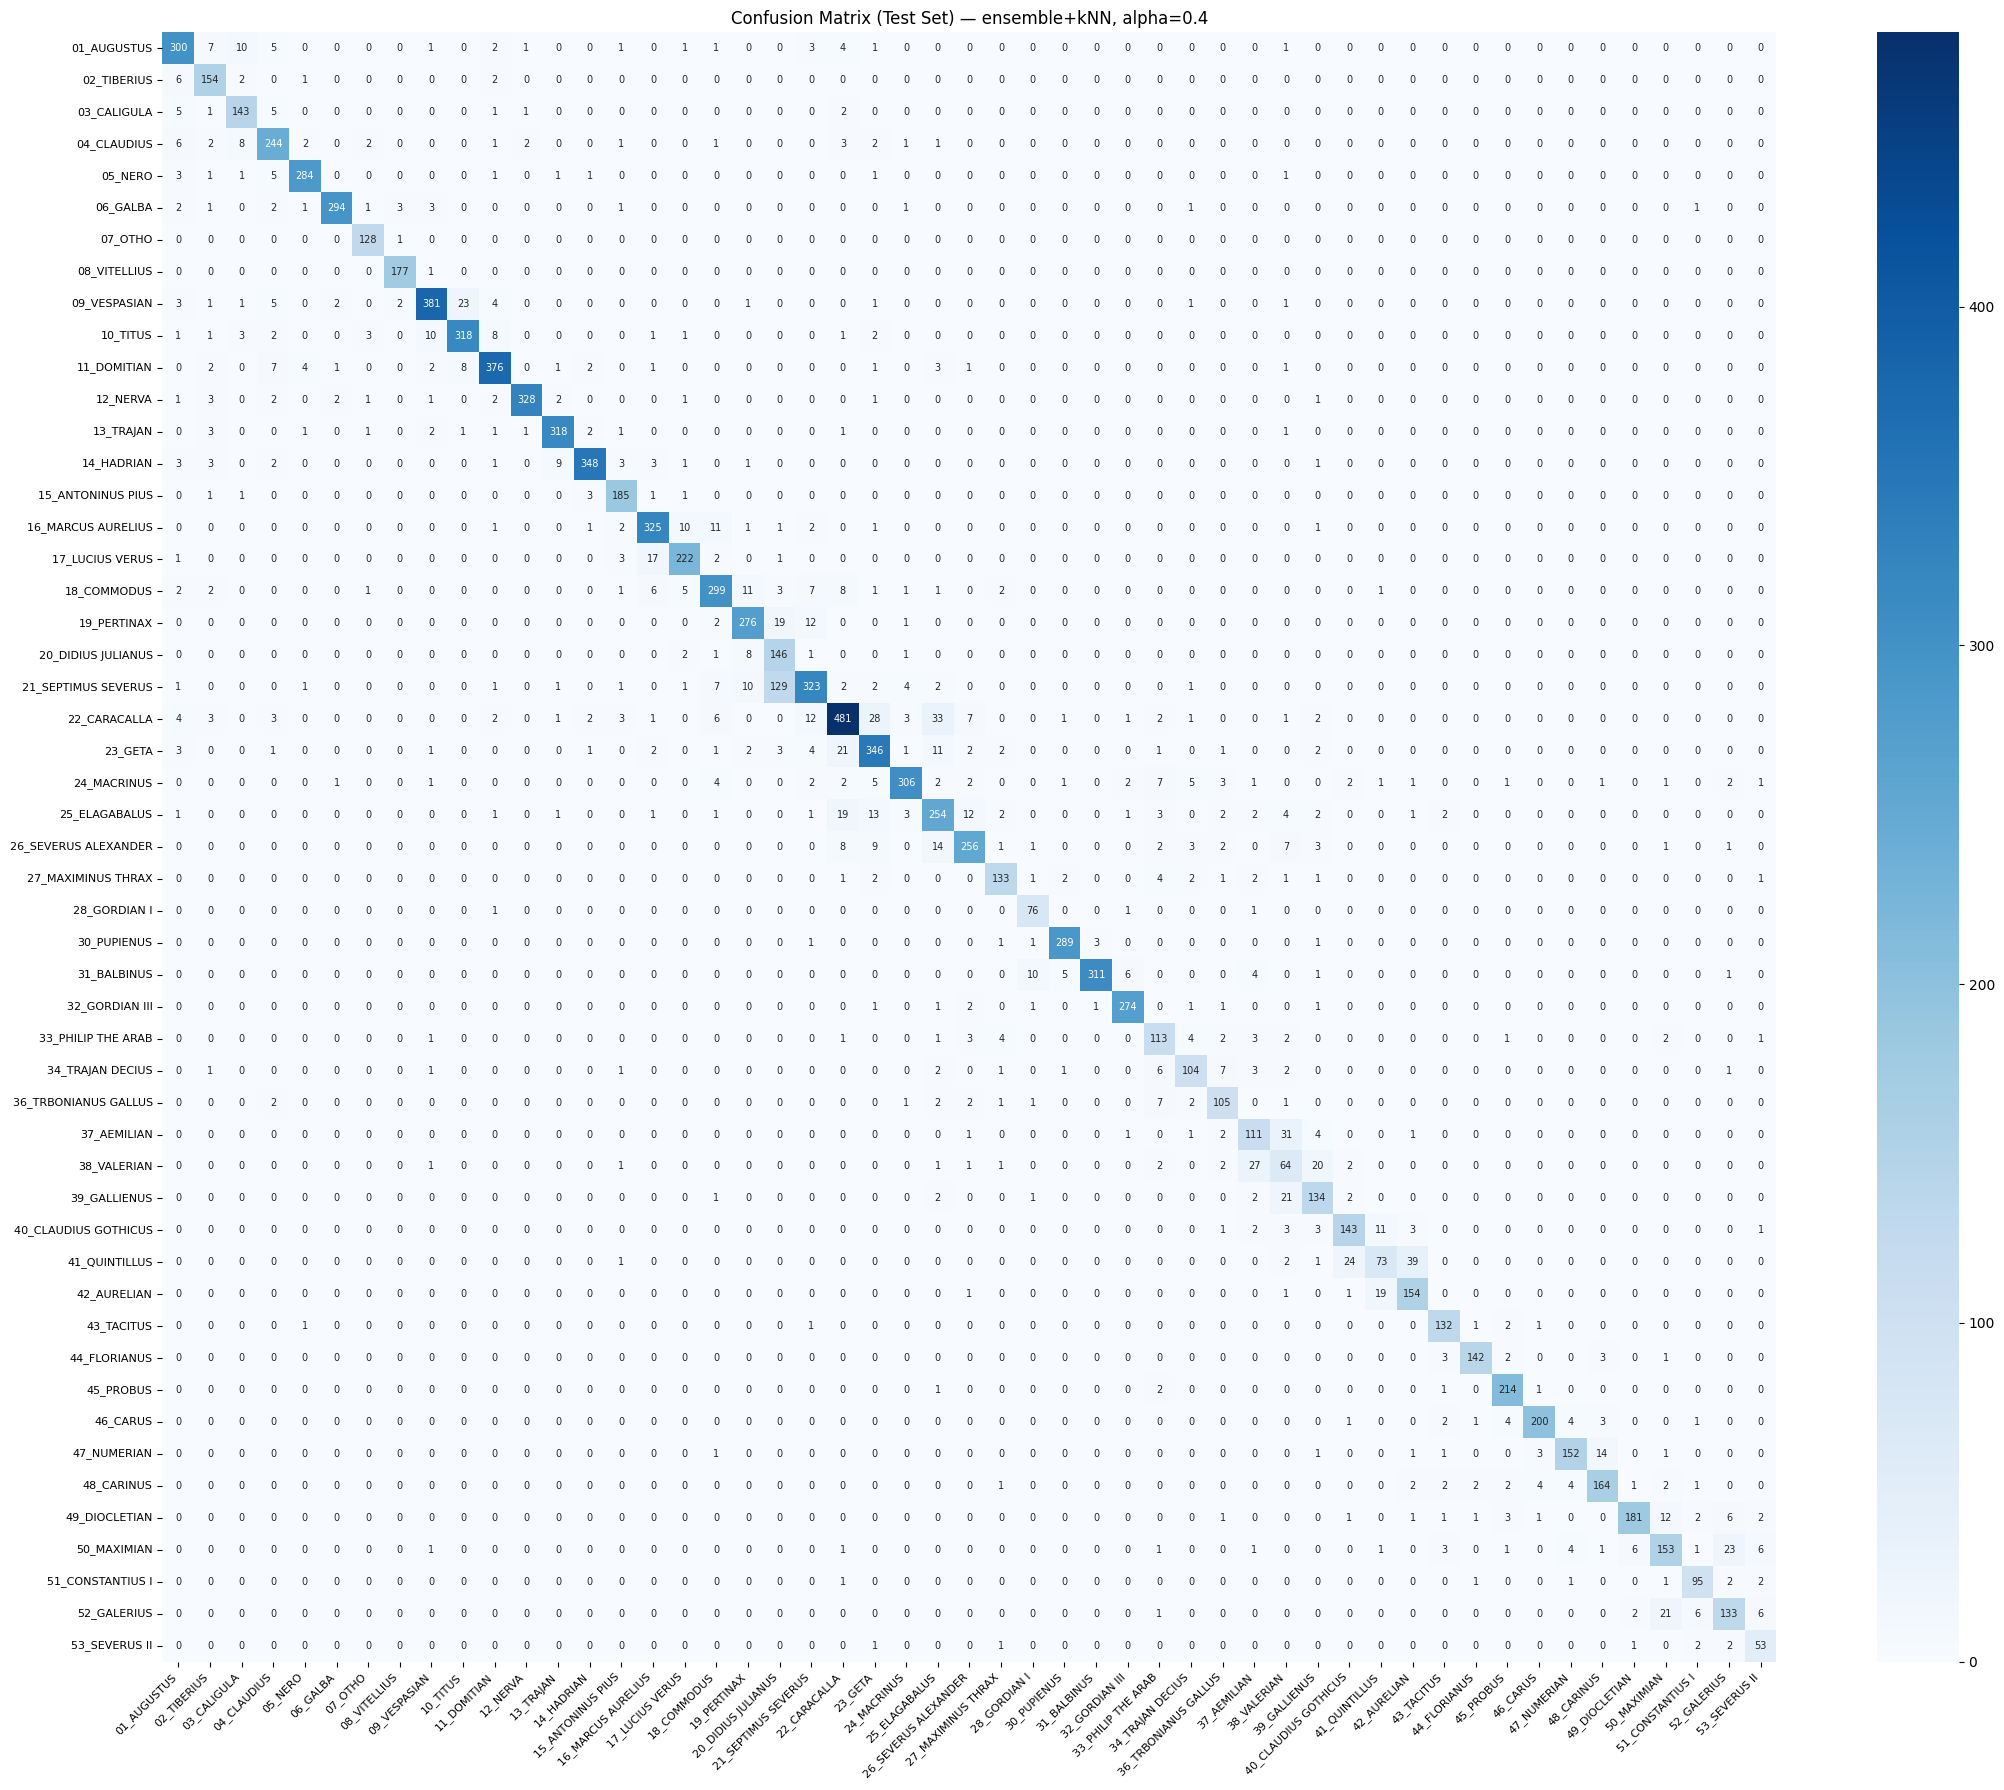

In [18]:
# Confusion matrix on the test set, ordered chronologically by emperor number.
class_order = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds = fused_predict(feats, best_alpha).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1

cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
            annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — ensemble+kNN, alpha={best_alpha}')
plt.tight_layout()
plt.show()


In [19]:
TOP_CONFUSIONS = 3

total_correct = int(cm.diagonal().sum())
total = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct/total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order_worst_first = np.argsort(row_acc)

print('Per-class breakdown (sorted by accuracy, worst first):')
for i in order_worst_first:
    n_total = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total} correct  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> predicted as {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other classes: {remaining}')


Overall test accuracy: 10915/12473 = 0.8751
Classes: 51

Per-class breakdown (sorted by accuracy, worst first):

41_QUINTILLUS: 73/140 correct  acc=0.521
  -> predicted as 42_AURELIAN: 39 (27.9%)
  -> predicted as 40_CLAUDIUS GOTHICUS: 24 (17.1%)
  -> predicted as 38_VALERIAN: 2 (1.4%)
  -> other classes: 2

38_VALERIAN: 64/122 correct  acc=0.525
  -> predicted as 37_AEMILIAN: 27 (22.1%)
  -> predicted as 39_GALLIENUS: 20 (16.4%)
  -> predicted as 33_PHILIP THE ARAB: 2 (1.6%)
  -> other classes: 9

21_SEPTIMUS SEVERUS: 323/486 correct  acc=0.665
  -> predicted as 20_DIDIUS JULIANUS: 129 (26.5%)
  -> predicted as 19_PERTINAX: 10 (2.1%)
  -> predicted as 18_COMMODUS: 7 (1.4%)
  -> other classes: 17

37_AEMILIAN: 111/152 correct  acc=0.730
  -> predicted as 38_VALERIAN: 31 (20.4%)
  -> predicted as 39_GALLIENUS: 4 (2.6%)
  -> predicted as 36_TRBONIANUS GALLUS: 2 (1.3%)
  -> other classes: 4

50_MAXIMIAN: 153/203 correct  acc=0.754
  -> predicted as 52_GALERIUS: 23 (11.3%)
  -> predicted a

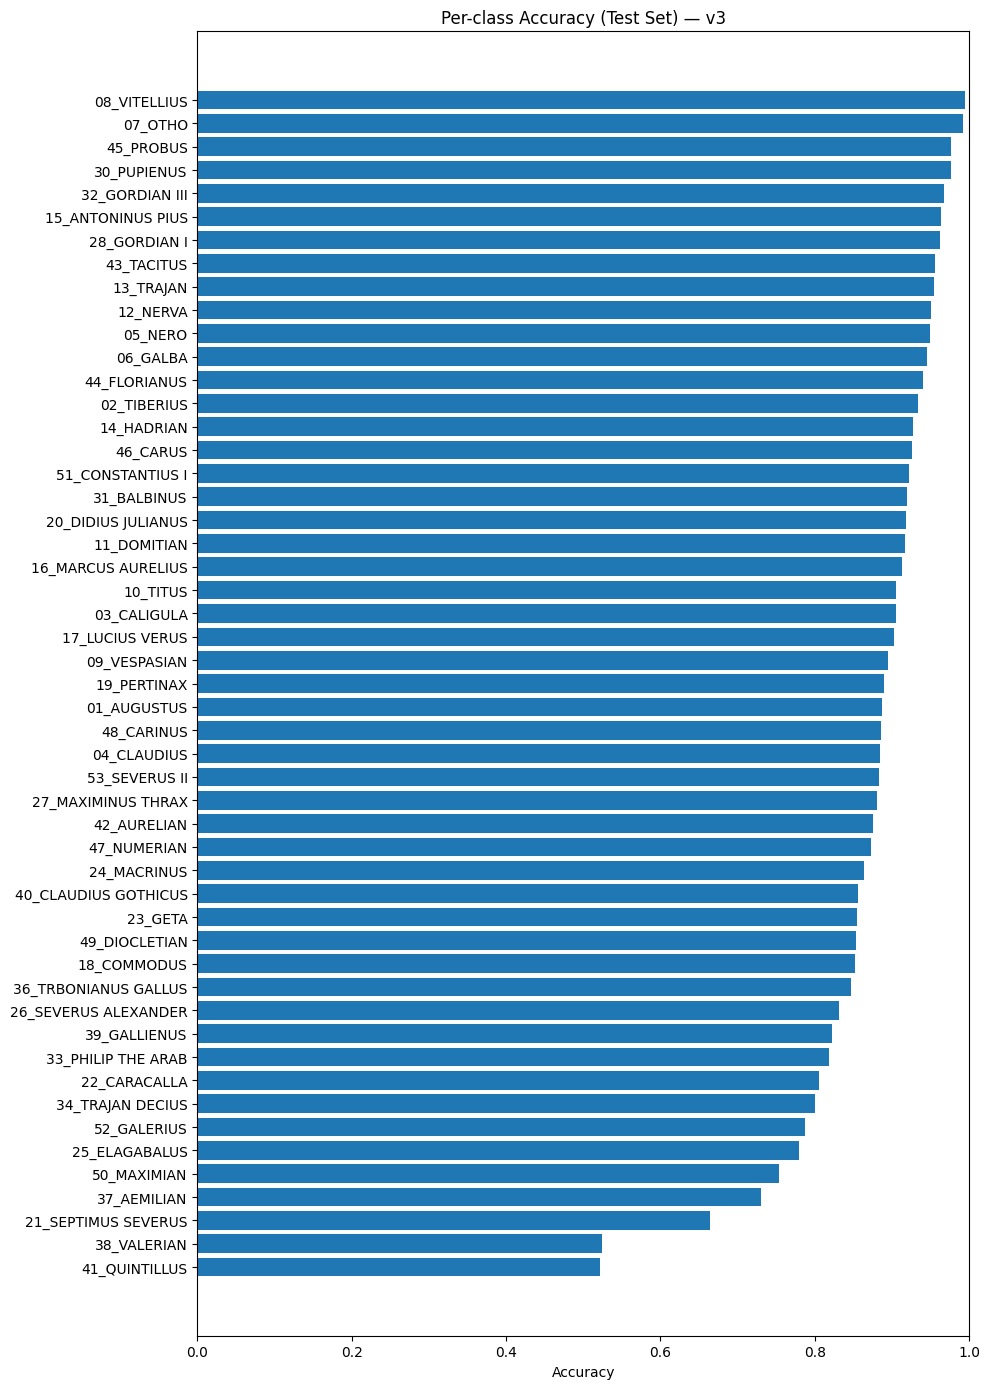

             Emperor  Accuracy
       41_QUINTILLUS  0.521429
         38_VALERIAN  0.524590
 21_SEPTIMUS SEVERUS  0.664609
         37_AEMILIAN  0.730263
         50_MAXIMIAN  0.753695
       25_ELAGABALUS  0.779141
         52_GALERIUS  0.786982
    34_TRAJAN DECIUS  0.800000
        22_CARACALLA  0.805695
  33_PHILIP THE ARAB  0.818841
        39_GALLIENUS  0.822086
26_SEVERUS ALEXANDER  0.831169
36_TRBONIANUS GALLUS  0.846774
         18_COMMODUS  0.851852
       49_DIOCLETIAN  0.853774
             23_GETA  0.854321
40_CLAUDIUS GOTHICUS  0.856287
         24_MACRINUS  0.864407
         47_NUMERIAN  0.873563
         42_AURELIAN  0.875000
  27_MAXIMINUS THRAX  0.880795
       53_SEVERUS II  0.883333
         04_CLAUDIUS  0.884058
          48_CARINUS  0.886486
         01_AUGUSTUS  0.887574
         19_PERTINAX  0.890323
        09_VESPASIAN  0.894366
     17_LUCIUS VERUS  0.902439
         03_CALIGULA  0.905063
            10_TITUS  0.905983
  16_MARCUS AURELIUS  0.912921
        

In [20]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': display_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set) — v3')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))


In [21]:
# ====================================================================
# OPTIONAL — biggest single gain available, but costs ~15 min of GPU time.
#
# Re-extract embeddings with test-time augmentation: horizontal flip + a second
# resolution (384) averaged into the original 256 vectors.  Then save the result
# as cradio_v4_embeddings_tta.pt and re-run all cells from the load step with
# this file instead.
#
# Set RUN_TTA = True to execute.  Leave False to skip.
# ====================================================================
RUN_TTA = False

if RUN_TTA:
    from torch.utils.data import Dataset
    from PIL import Image

    class CoinDataset(Dataset):
        def __init__(self, filepaths, labels, resolution=256, flip=False):
            self.filepaths = filepaths
            self.labels = labels
            self.resolution = resolution
            self.flip = flip
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            img = Image.open(self.filepaths[i]).convert('RGB')
            img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
            if self.flip:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
            return arr, torch.tensor(self.labels[i], dtype=torch.long)

    image_dir = Path(DATA_DIR)
    filepaths = sorted(image_dir.glob('*/side_a/*.jpg'))
    raw = [re.sub(r'^\d+_', '', p.parent.parent.name) for p in filepaths]
    # use the post-merge encoder
    src_to_dst = {v: v for v in label_encoder.values()}
    labs = []
    for n in raw:
        n2 = MERGES.get(n, n)
        labs.append(label_encoder[n2])

    @torch.no_grad()
    def extract(model, resolution, flip):
        ds = CoinDataset([str(p) for p in filepaths], labs,
                         resolution=resolution, flip=flip)
        loader = DataLoader(ds, batch_size=8, shuffle=False,
                            num_workers=2, pin_memory=True)
        feats = []
        for i, (imgs, _) in enumerate(loader):
            imgs = imgs.to(device)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                summary, _ = model(imgs)
            feats.append(summary.float().cpu())
            if (i + 1) % 200 == 0:
                print(f'    batch {i + 1}/{len(loader)}')
        return torch.cat(feats)

    print('Loading C-RADIO v4-H...')
    radio = torch.hub.load('NVlabs/RADIO', 'radio_model',
                           version='c-radio_v4-h', progress=True).to(device).eval()
    for p in radio.parameters():
        p.requires_grad = False

    print('Pass 1/4 -- 256, no flip')
    f1 = extract(radio, 256, False)
    print('Pass 2/4 -- 256, flip')
    f2 = extract(radio, 256, True)
    print('Pass 3/4 -- 384, no flip')
    f3 = extract(radio, 384, False)
    print('Pass 4/4 -- 384, flip')
    f4 = extract(radio, 384, True)

    avg = (f1 + f2 + f3 + f4) / 4.0
    out_path = Path(DATA_DIR) / 'cradio_v4_embeddings_tta.pt'
    torch.save({'features': avg,
                'labels': torch.tensor(labs, dtype=torch.long)}, out_path)
    print(f'Saved TTA embeddings -> {out_path}')
    print('Now edit cell 5 to load this file and re-run from there.')
